# Vertiefung Pandas GroupBy, Aggregation & Pivot

**Einordnung im Modul:** Datentransformation, Gruppierung, Aggregation und Pivotierung mit Pandas

**Kompetenzfokus:**
- Daten gruppieren und aggregieren
- Pivot-Tabellen erstellen und interpretieren
- Anwendung von `groupby()`, `agg()` und `pivot_table()` in Pandas
- Datenanalyse und -interpretation mit gruppierten Daten
- Anwendung von Funktionen auf gruppierte Daten

## Lernziele
| Stufe         | Lernziel: Ich kann…                                                                      |
| ------------- | ---------------------------------------------------------------------------------------- |
| 1 Erinnern    | den Zweck von `groupby()` und `pivot_table()` beschreiben.                               |
| 2 Verstehen   | erklären, wie Daten durch Gruppierung und Aggregation zusammengefasst werden.            |
| 2 Verstehen   | den Unterschied zwischen `groupby()` und `pivot_table()` erläutern.                      |
| 2 Verstehen   | beschreiben, wie `pivot_table()` Daten in eine neue tabellarische Struktur überführt.    |
| 3 Anwenden    | Daten mit `groupby()` nach einer oder mehreren Variablen gruppieren.                     |
| 3 Anwenden    | Aggregationsfunktionen (`mean`, `sum`, `count`) gezielt anwenden.                        |
| 3 Anwenden    | `pivot_table()` verwenden, um Daten nach Kategorien zu strukturieren und zu aggregieren. |
| 3 Anwenden    | mehrere Dimensionen (Zeilen, Spalten) in einer Pivot-Tabelle kombinieren.                |
| 4 Analysieren | entscheiden, ob `groupby()` oder `pivot_table()` für eine Analyse geeigneter ist.        |
| 4 Analysieren | Ergebnisse aus Aggregationen und Pivot-Tabellen interpretieren und vergleichen.          |

#### Pandas Groupby()


Die Funktion `groupby()` in Pandas ist ein mächtiges Werkzeug zur Datensegmentierung und -aggregation. Sie erlaubt es dir, deine Daten basierend auf einigen Kriterien in Gruppen zu unterteilen und dann aggregierte Berechnungen oder Transformationen auf diese Gruppen anzuwenden. Hier sind einige der wichtigsten Punkte, die du über Pandas `groupby()` wissen solltest:

Link zur Dokumentation: [pandas.DataFrame.groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html)


- Gruppierungsschlüssel: Du kannst nach einer oder mehreren Spalten gruppieren. Die Spalten, nach denen du gruppierst, werden als Gruppierungsschlüssel bezeichnet. Diese Schlüssel dienen als Basis, um die Datensätze in Gruppen aufzuteilen.

- Aggregation: Nachdem die Daten in Gruppen unterteilt wurden, kannst du Aggregationsfunktionen wie `sum()`, `mean()`, `max()`, `min()` und viele andere anwenden, um zusammengefasste Statistiken für jede Gruppe zu erhalten.

- Transformation: groupby kann auch verwendet werden, um Transformationen innerhalb jeder Gruppe durchzuführen, wie z.B. das Zentrieren der Daten um den Gruppendurchschnitt oder das Füllen von NA-Werten innerhalb jeder Gruppe mit einem gruppenspezifischen Wert.

- Filterung: Man kann die Gruppen auch filtern, um nur die Gruppen zu behalten, die bestimmte Kriterien erfüllen. Dies ist nützlich, um Ausreisser zu entfernen oder sich auf einen spezifischen Datenteil zu konzentrieren.

- Anwendung von benutzerdefinierten Funktionen: Neben vordefinierten Aggregations- und Transformationsfunktionen kannst du mit `apply()` eigene Funktionen auf Gruppenebene anwenden. Dies bietet eine hohe Flexibilität bei der Datenmanipulation.

- Hierarchische Indexierung: Die Ausgabe von groupby-Operationen kann eine hierarchische Indexstruktur (MultiIndex) aufweisen, wenn nach mehreren Spalten gruppiert wird. Dies ermöglicht eine detaillierte Segmentierung der Daten.

- Effizienz: groupby-Operationen sind in Pandas effizient implementiert und können grosse Datensätze relativ schnell verarbeiten. Es ist dennoch wichtig, die Performance im Auge zu behalten, besonders bei sehr grossen Datensätzen.

#### Beispiel Gruppierung nach einer Spalte oder mehreren Spalten & Abfrage nach Gruppen

In vielen Anwendungen müssen wir Daten nach Gruppen aufteilen anschliessend aggregieren und die Resultate wieder kombinieren. Pandas erlaubt es uns, Daten in Gruppen aufzuteilen und dann auf diesen Gruppen Berechnungen durchzuführen. 

Der erste Schritt beim Gruppieren besteht darin, die Daten in eine Gruppe von DataFrames aufzuteilen, die nach einem oder mehreren Kriterien gruppiert sind.
Die einfachste Möglichkeit, dies zu erreichen, besteht darin, die `groupby()`-Methode aufzurufen und die Spaltennamen anzugeben, nach denen gruppiert werden soll.

Wir verwendet die uns bereits bekannten Datensatz "patient_info.xlsx" um die Funktionsweise von `groupby()` zu demonstrieren.
- PatientID	
- Alter	
- Grösse	
- Gewicht	
- Raucher	
- Geschlecht	
- Blutgruppe	
- Rhesusfaktor

In [1]:
import pandas as pd
import seaborn as sns

df = pd.read_excel("patient_info.xlsx")

df

,PatientID,Alter,Grösse,Gewicht,Raucher,Geschlecht,Blutgruppe,Rhesusfaktor
0,0,69,167,94,True,m,AB,+
1,1,34,152,61,False,m,AB,+
2,2,31,160,70,False,m,0,-
3,3,75,196,110,False,m,A,+
4,4,41,169,58,True,w,A,+
...,...,...,...,...,...,...,...,...
9995,9995,55,192,61,True,m,B,+
9996,9996,52,176,115,False,m,AB,+
9997,9997,75,196,106,False,m,A,+
9998,9998,39,166,58,True,m,AB,-


In [2]:
# Gruppieren nach der Spalte Blutgruppe, per default findet die Gruppierung in der row axis statt
blutgruppe_group = df.groupby("Blutgruppe")
blutgruppe_group

In [3]:
# Wie sind die Gruppen aufgebaut?
blutgruppe_group.groups.items()

dict_items([('0', Index([   2,    5,   10,   15,   18,   23,   33,   37,   42,   47,
       ...
       9944, 9958, 9960, 9962, 9968, 9974, 9982, 9987, 9988, 9992],
      dtype='int64', length=2476)), ('A', Index([   3,    4,    6,    8,   19,   25,   36,   39,   44,   45,
       ...
       9951, 9952, 9961, 9963, 9970, 9973, 9976, 9986, 9991, 9997],
      dtype='int64', length=2508)), ('AB', Index([   0,    1,    9,   16,   17,   35,   40,   41,   43,   48,
       ...
       9965, 9969, 9979, 9980, 9983, 9984, 9989, 9996, 9998, 9999],
      dtype='int64', length=2415)), ('B', Index([   7,   11,   12,   13,   14,   20,   21,   22,   24,   26,
       ...
       9972, 9975, 9977, 9978, 9981, 9985, 9990, 9993, 9994, 9995],
      dtype='int64', length=2601))])

In [4]:
# Wie viele Einträge gibt es pro Gruppe?
blutgruppe_group.size()

Blutgruppe
0     2476
A     2508
AB    2415
B     2601
dtype: int64

In [5]:
# Zeige die Gruppen an mit den entsprechenden Werten an
pd.set_option("display.width", 100)

for blutgruppe, group in blutgruppe_group:
    print(blutgruppe)
    print(group)
    print("-------------------")

0
      PatientID  Alter  Grösse  Gewicht  Raucher Geschlecht Blutgruppe Rhesusfaktor
2             2     31     160       70    False          m          0            -
5             5     42     197      104     True          w          0            +
10           10     44     183       91    False          w          0            +
15           15     64     178       86     True          m          0            -
18           18     43     179      119     True          m          0            +
...         ...    ...     ...      ...      ...        ...        ...          ...
9974       9974     58     164       66    False          m          0            -
9982       9982     29     188       96     True          w          0            -
9987       9987     54     187       54    False          w          0            -
9988       9988     48     156      120    False          m          0            -
9992       9992     26     200      102    False          w          0    

In [6]:
# hole den ersten Eintrag der Gruppe
blutgruppe_group.first()

,PatientID,Alter,Grösse,Gewicht,Raucher,Geschlecht,Rhesusfaktor
Blutgruppe,,,,,,,
0,2,31,160,70,False,m,-
A,3,75,196,110,False,m,+
AB,0,69,167,94,True,m,+
B,7,63,196,117,True,w,-


In [7]:
# hole den letzten Eintrag der Gruppe
blutgruppe_group.last()

,PatientID,Alter,Grösse,Gewicht,Raucher,Geschlecht,Rhesusfaktor
Blutgruppe,,,,,,,
0,9992,26,200,102,False,w,-
A,9997,75,196,106,False,m,+
AB,9999,70,187,69,False,m,+
B,9995,55,192,61,True,m,+


In [8]:
# hole den einen bestimmten Eintrag der Gruppe
blutgruppe_group.get_group("0")

,PatientID,Alter,Grösse,Gewicht,Raucher,Geschlecht,Blutgruppe,Rhesusfaktor
2,2,31,160,70,False,m,0,-
5,5,42,197,104,True,w,0,+
10,10,44,183,91,False,w,0,+
15,15,64,178,86,True,m,0,-
18,18,43,179,119,True,m,0,+
...,...,...,...,...,...,...,...,...
9974,9974,58,164,66,False,m,0,-
9982,9982,29,188,96,True,w,0,-
9987,9987,54,187,54,False,w,0,-
9988,9988,48,156,120,False,m,0,-


In [9]:
# Erste Gruppe Blutgruppe, zweite Gruppe Rhesusfaktor
blutgruppe_rhesus_group = df.groupby(["Blutgruppe", "Rhesusfaktor"])
blutgruppe_rhesus_group.first()

PatientID  Alter  Grösse  Gewicht  Raucher Geschlecht
Blutgruppe Rhesusfaktor                                                       
0          +                     5     42     197      104     True          w
           -                     2     31     160       70    False          m
A          +                     3     75     196      110    False          m
           -                     6     80     194      113    False          w
AB         +                     0     69     167       94     True          m
           -                     9     40     168      107    False          m
B          +                    11     36     183       87     True          w
           -                     7     63     196      117     True          w

In [10]:
# Kehren wir die Gruppen um
rhesus_blutgruppe_group = df.groupby(["Rhesusfaktor", "Blutgruppe"])
rhesus_blutgruppe_group.first()

PatientID  Alter  Grösse  Gewicht  Raucher Geschlecht
Rhesusfaktor Blutgruppe                                                       
+            0                   5     42     197      104     True          w
             A                   3     75     196      110    False          m
             AB                  0     69     167       94     True          m
             B                  11     36     183       87     True          w
-            0                   2     31     160       70    False          m
             A                   6     80     194      113    False          w
             AB                  9     40     168      107    False          m
             B                   7     63     196      117     True          w

In [11]:
# Hole die Gruppe Rehesusfaktor negativ und Blutgruppe 0
rhesus_blutgruppe_group.get_group(("-", "0"))

,PatientID,Alter,Grösse,Gewicht,Raucher,Geschlecht,Blutgruppe,Rhesusfaktor
2,2,31,160,70,False,m,0,-
15,15,64,178,86,True,m,0,-
42,42,37,171,92,True,w,0,-
47,47,50,196,77,False,m,0,-
58,58,20,193,65,True,w,0,-
...,...,...,...,...,...,...,...,...
9974,9974,58,164,66,False,m,0,-
9982,9982,29,188,96,True,w,0,-
9987,9987,54,187,54,False,w,0,-
9988,9988,48,156,120,False,m,0,-


Wir haben bisher betrachtet, wie wir die Daten nach einer Spalte gruppieren können. Auch haben wir kennengelert wie die Daten nach mehreren Spalten gruppiert werden können. 
Dazu übergeben wir der `groupby()`-Methode eine Liste mit den Spaltennamen, nach denen gruppiert werden soll.
Wir haben auch betrachtet dass man mit der `get_group()`-Methode eine bestimmte Gruppe (auch Kombination von Gruppen) auswählen können. Ebenfalls haben wir uns mit der `groups`-Attribut die Gruppen anzeigen lassen.

#### Beispiele mit Agg-Funktionen und benutzerdefinierten Funktionen

Nachdem wir die Daten in Gruppen aufgeteilt haben, können wir eine Aggregatfunktion auf jede Gruppe anwenden.
Wir werden uns die direkten Aggregatfunktionen wie `sum()`, `mean()`, `median()`, `min()`, `max()` und `count()` anschauen. Komplette Liste der Built-in Aggregatfunktionen: https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html#built-in-aggregation-methods
Ebenfalls werden wir uns die `agg()`-Methode anschauen, mit der wir eine beliebige Aggregatfunktion auf eine Gruppe anwenden können.

In [12]:
blutgruppe_group = df.groupby("Blutgruppe")

# Summen der numerischen Spalten
# blutgruppe_group.sum()
blutgruppe_group[["Alter", "Grösse", "Gewicht"]].sum()

,Alter,Grösse,Gewicht
Blutgruppe,,,
0,123783,435724,211252
A,125419,437887,214008
AB,120172,422160,204236
B,129259,454614,219399


In [13]:
# Durschnitt der numerischen Spalten
# blutgruppe_group.mean()
blutgruppe_group[["Alter", "Grösse", "Gewicht"]].mean()
# possible functions https://pandas.pydata.org/docs/reference/groupby.html

,Alter,Grösse,Gewicht
Blutgruppe,,,
0,49.993134,175.978998,85.319871
A,50.007576,174.596093,85.330144
AB,49.760663,174.807453,84.569772
B,49.695886,174.784314,84.351788


In [14]:
# Aggregation mit mehreren Funktionen
blutgruppe_group[["Alter", "Grösse", "Gewicht"]].agg(["mean", "median"])

Alter             Grösse           Gewicht       
                 mean median        mean median       mean median
Blutgruppe                                                       
0           49.993134   50.0  175.978998  176.0  85.319871   86.0
A           50.007576   50.0  174.596093  175.0  85.330144   86.0
AB          49.760663   50.0  174.807453  175.0  84.569772   84.0
B           49.695886   50.0  174.784314  175.0  84.351788   84.0

In [15]:
blutgruppe_group[["Alter", "Grösse", "Gewicht"]].agg(
    ["mean", "sum", "median", "std", "count"]
)

Alter                                      Grösse                                  \
                 mean     sum median        std count        mean     sum median        std count   
Blutgruppe                                                                                          
0           49.993134  123783   50.0  17.420954  2476  175.978998  435724  176.0  14.880492  2476   
A           50.007576  125419   50.0  17.597060  2508  174.596093  437887  175.0  14.724052  2508   
AB          49.760663  120172   50.0  17.972266  2415  174.807453  422160  175.0  14.946875  2415   
B           49.695886  129259   50.0  17.490706  2601  174.784314  454614  175.0  14.737263  2601   

              Gewicht                                  
                 mean     sum median        std count  
Blutgruppe                                             
0           85.319871  211252   86.0  20.477321  2476  
A           85.330144  214008   86.0  20.438283  2508  
AB          84.569772  204236   84.0  20.681692  2415  
B           84.351788  219399   84.0  20.498209  2601

In [16]:
var = blutgruppe_group[["Alter", "Grösse", "Gewicht"]].agg(
    ["mean", "sum", "median", "std", "count"]
)

var["Gewicht"]["mean"]

Blutgruppe
0     85.319871
A     85.330144
AB    84.569772
B     84.351788
Name: mean, dtype: float64

In [17]:
# agg mit mehreren Gruppen
df.groupby(["Blutgruppe", "Rhesusfaktor"])[["Alter", "Grösse", "Gewicht"]].agg(
    ["mean", "sum", "median", "std", "count"]
)

Alter                                     Grösse                 \
                              mean    sum median        std count        mean     sum median   
Blutgruppe Rhesusfaktor                                                                        
0          +             49.968724  60712   50.0  17.311108  1215  175.624691  213384  176.0   
           -             50.016653  63071   50.0  17.532977  1261  176.320381  222340  177.0   
A          +             49.523923  62103   49.0  17.724656  1254  174.137959  218369  174.0   
           -             50.491228  63316   51.0  17.462202  1254  175.054226  219518  176.0   
AB         +             49.804714  59168   50.0  17.809407  1188  174.771886  207629  175.0   
           -             49.718011  61004   49.0  18.135714  1227  174.841891  214531  174.0   
B          +             50.112199  66549   50.0  17.579152  1328  174.743223  232059  174.0   
           -             49.261587  62710   50.0  17.394242  1273  174.827180  222555  175.0   

                                            Gewicht                                  
                               std count       mean     sum median        std count  
Blutgruppe Rhesusfaktor                                                              
0          +             14.972156  1215  85.970370  104454   87.0  20.360324  1215  
           -             14.789544  1261  84.693101  106798   85.0  20.578040  1261  
A          +             14.606166  1254  85.625997  107375   86.0  20.431295  1254  
           -             14.832674  1254  85.034290  106633   85.0  20.449137  1254  
AB         +             14.654953  1188  85.389731  101443   85.0  20.330806  1188  
           -             15.230082  1227  83.775876  102793   82.0  20.993617  1227  
B          +             14.831976  1328  84.466867  112172   85.0  20.776823  1328  
           -             14.643510  1273  84.231736  107227   84.0  20.210929  1273

In [18]:
# agg mit mehreren Gruppen und eigenen Namen für aggregierte Spalten

df.groupby(["Blutgruppe", "Rhesusfaktor"]).agg(
    Grösse_mean=("Grösse", "mean"),
    Grösse_median=("Grösse", "median"),
    Gewicht_mean=("Gewicht", "mean"),
    Gewicht_sum=("Gewicht", "sum"),
)

Grösse_mean  Grösse_median  Gewicht_mean  Gewicht_sum
Blutgruppe Rhesusfaktor                                                       
0          +              175.624691          176.0     85.970370       104454
           -              176.320381          177.0     84.693101       106798
A          +              174.137959          174.0     85.625997       107375
           -              175.054226          176.0     85.034290       106633
AB         +              174.771886          175.0     85.389731       101443
           -              174.841891          174.0     83.775876       102793
B          +              174.743223          174.0     84.466867       112172
           -              174.827180          175.0     84.231736       107227

In [19]:
# 25th Percentile
def q25(x):
    return x.quantile(0.25)


# 75th Percentile
def q75(x):
    return x.quantile(0.75)


# agg mit mehreren Gruppen
df.groupby(["Blutgruppe", "Rhesusfaktor"])[["Alter", "Grösse", "Gewicht"]].agg(
    ["mean", "sum", "median", q25, q75]
)

Alter                                Grösse                         \
                              mean    sum median   q25   q75        mean     sum median     q25   
Blutgruppe Rhesusfaktor                                                                           
0          +             49.968724  60712   50.0  35.0  65.0  175.624691  213384  176.0  162.00   
           -             50.016653  63071   50.0  35.0  65.0  176.320381  222340  177.0  163.00   
A          +             49.523923  62103   49.0  34.0  65.0  174.137959  218369  174.0  161.25   
           -             50.491228  63316   51.0  36.0  65.0  175.054226  219518  176.0  163.00   
AB         +             49.804714  59168   50.0  34.0  65.0  174.771886  207629  175.0  162.00   
           -             49.718011  61004   49.0  34.0  66.0  174.841891  214531  174.0  161.00   
B          +             50.112199  66549   50.0  35.0  65.0  174.743223  232059  174.0  162.00   
           -             49.261587  62710   50.0  34.0  64.0  174.827180  222555  175.0  162.00   

                                  Gewicht                              
                           q75       mean     sum median   q25    q75  
Blutgruppe Rhesusfaktor                                                
0          +             189.0  85.970370  104454   87.0  69.0  104.0  
           -             190.0  84.693101  106798   85.0  67.0  102.0  
A          +             186.0  85.625997  107375   86.0  68.0  103.0  
           -             188.0  85.034290  106633   85.0  68.0  102.0  
AB         +             188.0  85.389731  101443   85.0  68.0  103.0  
           -             189.0  83.775876  102793   82.0  65.0  102.0  
B          +             187.0  84.466867  112172   85.0  66.0  103.0  
           -             187.0  84.231736  107227   84.0  67.0  101.0

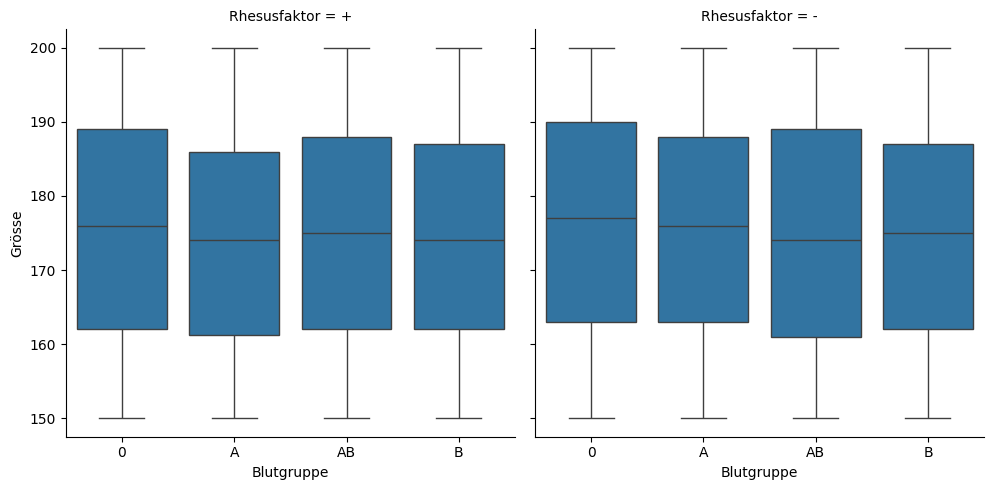

In [20]:
# Schauen wir uns die Verteilungen in einem Boxplot an
sns.catplot(
    data=df,
    x="Blutgruppe",
    y="Grösse",
    kind="box",
    col="Rhesusfaktor",
    order=["0", "A", "AB", "B"],
    col_order=["+", "-"],
)

In [21]:
# Gruppierung nach der Spalte species und Aggregation der Spalte bill_length_mm & bill_depth_mm
df.groupby("Blutgruppe").agg({"Grösse": lambda x: list(x)})

,Grösse
Blutgruppe,
0,"[160, 197, 183, 178, 179, 193, 194, 162, 171, ..."
A,"[196, 169, 194, 166, 160, 180, 161, 177, 194, ..."
AB,"[167, 152, 168, 151, 185, 188, 186, 153, 198, ..."
B,"[196, 183, 196, 165, 173, 175, 197, 166, 182, ..."


In [22]:
# Gruppierung nach der Spalte Blutgruppe und Aggregation der Spalte Grösse & Gewicht mit unterschiedlichen Aggregationsfunktionen
df.groupby("Blutgruppe").agg(
    {"Grösse": ["mean", "median", "std"], "Gewicht": ["mean", "sum"]}
)

Grösse                      Gewicht        
                  mean median        std       mean     sum
Blutgruppe                                                 
0           175.978998  176.0  14.880492  85.319871  211252
A           174.596093  175.0  14.724052  85.330144  214008
AB          174.807453  175.0  14.946875  84.569772  204236
B           174.784314  175.0  14.737263  84.351788  219399

#### Beispiel mit Transformationen

Neben der Aggregation können wir auch Transformationen auf Gruppenebene durchführen.

In [23]:
# Beispiel mit Transformationsfunktion Normalisierung der Grösse innerhalb jeder Gruppe:
df["Grösse_zscore"] = df.groupby("Blutgruppe")["Grösse"].transform(
    lambda x: (x - x.mean()) / x.std()
)
df

,PatientID,Alter,Grösse,Gewicht,Raucher,Geschlecht,Blutgruppe,Rhesusfaktor,Grösse_zscore
0,0,69,167,94,True,m,AB,+,-0.522347
1,1,34,152,61,False,m,AB,+,-1.525901
2,2,31,160,70,False,m,0,-,-1.073822
3,3,75,196,110,False,m,A,+,1.453670
4,4,41,169,58,True,w,A,+,-0.380065
...,...,...,...,...,...,...,...,...,...
9995,9995,55,192,61,True,m,B,+,1.168174
9996,9996,52,176,115,False,m,AB,+,0.079786
9997,9997,75,196,106,False,m,A,+,1.453670
9998,9998,39,166,58,True,m,AB,-,-0.589251


#### Beispiel mit Filterung

Wir können die Gruppen auch filtern, um nur die Gruppen zu behalten, die bestimmte Kriterien erfüllen. Dies ist nützlich, um Ausreisser zu entfernen oder sich auf einen spezifischen Datenteil zu konzentrieren.

In [24]:
# Beispiel mit Filterfunktion
df.groupby("Blutgruppe").filter(lambda x: x["Grösse"].mean() > 175)

,PatientID,Alter,Grösse,Gewicht,Raucher,Geschlecht,Blutgruppe,Rhesusfaktor,Grösse_zscore
2,2,31,160,70,False,m,0,-,-1.073822
5,5,42,197,104,True,w,0,+,1.412655
10,10,44,183,91,False,w,0,+,0.471826
15,15,64,178,86,True,m,0,-,0.135816
18,18,43,179,119,True,m,0,+,0.203018
...,...,...,...,...,...,...,...,...,...
9974,9974,58,164,66,False,m,0,-,-0.805014
9982,9982,29,188,96,True,w,0,-,0.807836
9987,9987,54,187,54,False,w,0,-,0.740634
9988,9988,48,156,120,False,m,0,-,-1.342630


### Pivot-Tabellen

In [25]:
# Erstellen einer pandas groupby object
df.groupby(["Blutgruppe"])["Grösse"].agg(["mean", "sum"])

,mean,sum
Blutgruppe,,
0,175.978998,435724
A,174.596093,437887
AB,174.807453,422160
B,174.784314,454614


In [26]:
df.groupby(["Blutgruppe", "Rhesusfaktor"])["Grösse"].agg(["mean", "sum"])

mean     sum
Blutgruppe Rhesusfaktor                    
0          +             175.624691  213384
           -             176.320381  222340
A          +             174.137959  218369
           -             175.054226  219518
AB         +             174.771886  207629
           -             174.841891  214531
B          +             174.743223  232059
           -             174.827180  222555

In [27]:
# Erstellen eine pandas pivot table
blutgruppe_rhesus_pivot = df.pivot_table(
    index="Blutgruppe",
    columns="Rhesusfaktor",
    values="Grösse",
    aggfunc=["mean", "sum"],
    fill_value=0,
)
blutgruppe_rhesus_pivot

mean                 sum        
Rhesusfaktor           +           -       +       -
Blutgruppe                                          
0             175.624691  176.320381  213384  222340
A             174.137959  175.054226  218369  219518
AB            174.771886  174.841891  207629  214531
B             174.743223  174.827180  232059  222555

In [28]:
# wähle wert aus der pivot table
blutgruppe_rhesus_pivot.loc["0"]["mean"]["-"]

np.float64(176.32038065027757)

In [29]:
# wert über spaltennamen auswählen
blutgruppe_rhesus_pivot["mean"]["-"]["0"]

np.float64(176.32038065027757)